In [2]:
#upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asadejaz12","key":"5b03896240ef9b7cfc3f6cdff2d5a5a6"}'}

In [3]:
#create kaggle directory
!mkdir ~/.kaggle


In [4]:
#copy kaggle.json file
!cp kaggle.json ~/.kaggle/

In [5]:
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d 'ahmedashrafahmed/bone-fracture'

Dataset URL: https://www.kaggle.com/datasets/ahmedashrafahmed/bone-fracture
License(s): unknown
100% 88.4M/88.4M [00:03<00:00, 29.8MB/s]



In [7]:
!unzip bone-fracture.zip

Archive:  bone-fracture.zip
  inflating: dataset/.ipynb_checkpoints/desktop.ini  
  inflating: dataset/desktop.ini     
  inflating: dataset/test/desktop.ini  
  inflating: dataset/test/fractured/1-rotated1-rotated2-rotated1.jpg  
  inflating: dataset/test/fractured/1-rotated1-rotated3-rotated3 - Copy.jpg  
  inflating: dataset/test/fractured/1-rotated2-rotated1-rotated3.jpg  
  inflating: dataset/test/fractured/1-rotated2-rotated3-rotated1 - Copy.jpg  
  inflating: dataset/test/fractured/1-rotated3-rotated1-rotated1.jpg  
  inflating: dataset/test/fractured/1-rotated3-rotated2-rotated3 - Copy.jpg  
  inflating: dataset/test/fractured/2-rotated1-rotated2 - Copy.jpg  
  inflating: dataset/test/fractured/2-rotated1-rotated3-rotated2 - Copy.jpg  
  inflating: dataset/test/fractured/2-rotated2-rotated1-rotated2.jpg  
  inflating: dataset/test/fractured/2-rotated2-rotated3 - Copy.jpg  
  inflating: dataset/test/fractured/2-rotated3-rotated1.jpg  
  inflating: dataset/test/fractured/2-rotate

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,Input, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score
BATCH_SIZE = 32
IMG_SIZE = (256, 256)
SEED = 42

In [11]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dataset/train',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

#validation 20% of training dataset
validation_ds =  keras.utils.image_dataset_from_directory(
    directory='/content/dataset/train',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

#untouched dataset used later for testing
test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/dataset/test',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

Found 4097 files belonging to 2 classes.
Using 3278 files for training.
Found 4097 files belonging to 2 classes.
Using 819 files for validation.
Found 399 files belonging to 2 classes.


In [12]:
#create cnn model
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

cnn = Sequential()

cnn.add(Input(shape=(256, 256, 3)))
cnn.add(layers.Rescaling(1./255))
cnn.add(data_augmentation)

cnn.add(Conv2D(32, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(64, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(128, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(GlobalAveragePooling2D())
cnn.add(Dropout(0.4))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.3))
cnn.add(Dense(1, activation='sigmoid'))

In [13]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [15]:
history = cnn.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds,
    verbose=1
)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.6650 - loss: 0.6066 - val_accuracy: 0.5104 - val_loss: 0.7513
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.7392 - loss: 0.5424 - val_accuracy: 0.5104 - val_loss: 0.8787
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.7621 - loss: 0.5016 - val_accuracy: 0.5189 - val_loss: 0.7329
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.7657 - loss: 0.4707 - val_accuracy: 0.5128 - val_loss: 0.8675
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.7733 - loss: 0.4687 - val_accuracy: 0.5214 - val_loss: 0.9137
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.8029 - loss: 0.4303 - val_accuracy: 0.5421 - val_loss: 1.0621
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.8075 - loss: 0.4119 - val_accuracy: 0.6935 - val_loss: 0.6822
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.8084 - loss: 0

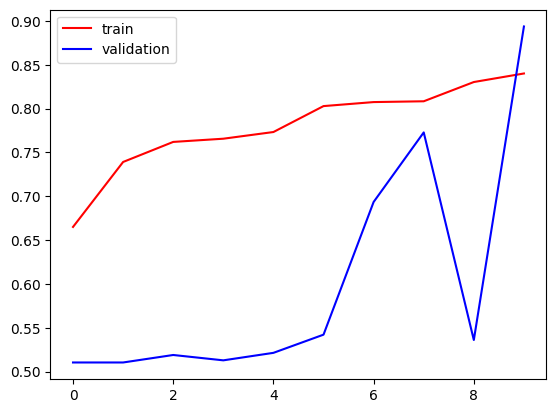

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

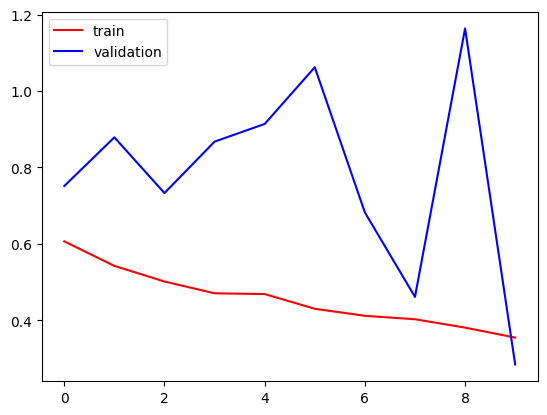

In [17]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()


In [18]:
cnn.evaluate(test_ds)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8922 - loss: 0.2760


[0.27604374289512634, 0.8922305703163147]

In [19]:
cnn.save('bone-fracture.keras')